# Phase 5 — Resampling & gestion du déséquilibre

Le train contient **376 fraudes pour 209 916 légitimes** (ratio 1/558).  
Cette phase compare 5 stratégies de rééquilibrage sur un modèle rapide  
(LogisticRegression) et sélectionne la meilleure pour les phases 6–7.

## Règle absolue
> Tout resampling est appliqué **uniquement sur le train**.  
> Le test reste intact — il représente la distribution réelle en production.

## Stratégies comparées
| # | Stratégie | Principe |
|---|---|---|
| 0 | Aucun resampling | Baseline brut |
| 1 | `class_weight='balanced'` | Pondère les exemples sans modifier les données |
| 2 | Random Undersampling | Réduit la classe majoritaire |
| 3 | SMOTE | Génère des fraudes synthétiques |
| 4 | SMOTE + Undersampling (SMOTETomek) | Combine les deux |

## Plan
1. Chargement & prétraitement
2. Comparaison des stratégies
3. Spot-check SMOTE (vérification des artefacts)
4. Visualisation des distributions
5. Sélection finale
6. Conclusions

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                              classification_report, confusion_matrix)
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine        import SMOTETomek

from src.config import RANDOM_SEED, SCALE_POS_WEIGHT

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement & prétraitement

In [2]:
# Charger les splits enrichis (Phase 4)
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

# Charger le preprocessor et la config des features
preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)

FEAT_COLS = feat_cfg['all_feat_cols']

# Transformer (preprocessor déjà fitté sur train en Phase 4)
X_train = preprocessor.transform(train[FEAT_COLS])
X_test  = preprocessor.transform(test[FEAT_COLS])
y_train = train['Class'].values
y_test  = test['Class'].values

print(f'X_train : {X_train.shape} | fraudes : {y_train.sum()}')
print(f'X_test  : {X_test.shape}  | fraudes : {y_test.sum()}')
print(f'Ratio train : 1 fraude / {int((y_train==0).sum() / y_train.sum())} légitimes')

X_train : (210292, 35) | fraudes : 376
X_test  : (73434, 35)  | fraudes : 97
Ratio train : 1 fraude / 558 légitimes


## 2. Comparaison des stratégies de resampling

On entraîne une **LogisticRegression** (rapide, reproductible) avec chaque stratégie  
et on évalue sur le **test intact**. Métriques : AUPRC (principale), F1-fraude, rappel-fraude.

In [3]:
def evaluate(name, X_tr, y_tr, X_te, y_te, class_weight=None):
    """Entraîne une LR et retourne les métriques sur le test."""
    clf = LogisticRegression(
        max_iter=1000, random_state=RANDOM_SEED,
        class_weight=class_weight
    )
    clf.fit(X_tr, y_tr)
    scores  = clf.predict_proba(X_te)[:, 1]
    preds   = clf.predict(X_te)
    auprc   = average_precision_score(y_te, scores)
    report  = classification_report(y_te, preds, output_dict=True)
    fraud_m = report.get('1', {})
    return {
        'Stratégie'     : name,
        'AUPRC'         : round(auprc, 4),
        'Rappel fraude' : round(fraud_m.get('recall', 0), 4),
        'Précision fraude': round(fraud_m.get('precision', 0), 4),
        'F1 fraude'     : round(fraud_m.get('f1-score', 0), 4),
        'n_train'       : len(y_tr),
        'n_fraudes_train': int(y_tr.sum()),
    }, scores

results = []
all_scores = {}

# 0. Aucun resampling
r, s = evaluate('0 — Aucun resampling', X_train, y_train, X_test, y_test)
results.append(r); all_scores[r['Stratégie']] = s
print(f"[0] Aucun resampling        — AUPRC : {r['AUPRC']}")

# 1. class_weight='balanced'
r, s = evaluate('1 — class_weight balanced', X_train, y_train, X_test, y_test,
                class_weight='balanced')
results.append(r); all_scores[r['Stratégie']] = s
print(f"[1] class_weight balanced   — AUPRC : {r['AUPRC']}")

# 2. Random Undersampling
rus = RandomUnderSampler(random_state=RANDOM_SEED)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
r, s = evaluate('2 — Random Undersampling', X_rus, y_rus, X_test, y_test)
results.append(r); all_scores[r['Stratégie']] = s
print(f"[2] Random Undersampling    — AUPRC : {r['AUPRC']}  "
      f"(train réduit : {len(y_rus):,} lignes)")

# 3. SMOTE
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train, y_train)
r, s = evaluate('3 — SMOTE', X_sm, y_sm, X_test, y_test)
results.append(r); all_scores[r['Stratégie']] = s
print(f"[3] SMOTE                   — AUPRC : {r['AUPRC']}  "
      f"(train élargi : {len(y_sm):,} lignes)")

# 4. SMOTETomek
smt = SMOTETomek(random_state=RANDOM_SEED)
X_smt, y_smt = smt.fit_resample(X_train, y_train)
r, s = evaluate('4 — SMOTETomek', X_smt, y_smt, X_test, y_test)
results.append(r); all_scores[r['Stratégie']] = s
print(f"[4] SMOTETomek              — AUPRC : {r['AUPRC']}  "
      f"(train : {len(y_smt):,} lignes)")

[0] Aucun resampling        — AUPRC : 0.7406
[1] class_weight balanced   — AUPRC : 0.7845
[2] Random Undersampling    — AUPRC : 0.5606  (train réduit : 752 lignes)
[3] SMOTE                   — AUPRC : 0.7966  (train élargi : 419,832 lignes)
[4] SMOTETomek              — AUPRC : 0.7966  (train : 419,832 lignes)


In [4]:
# Tableau récapitulatif
df_res = pd.DataFrame(results)
df_res = df_res.sort_values('AUPRC', ascending=False).reset_index(drop=True)
print('\n=== Résultats comparatifs (LogisticRegression sur test) ===')
print(df_res.to_string(index=False))


=== Résultats comparatifs (LogisticRegression sur test) ===
                Stratégie  AUPRC  Rappel fraude  Précision fraude  F1 fraude  n_train  n_fraudes_train
           4 — SMOTETomek 0.7966         0.8969            0.0228     0.0444   419832           209916
                3 — SMOTE 0.7966         0.8969            0.0228     0.0444   419832           209916
1 — class_weight balanced 0.7845         0.9072            0.0232     0.0453   210292              376
     0 — Aucun resampling 0.7406         0.5773            0.8235     0.6788   210292              376
 2 — Random Undersampling 0.5606         0.9072            0.0190     0.0372      752              376


## 3. Courbes précision-rappel

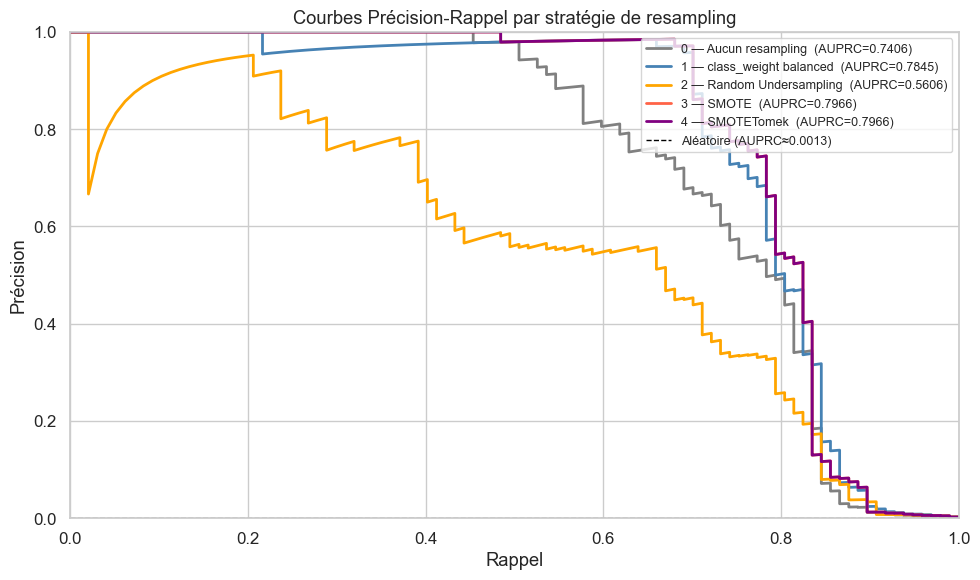

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gray', 'steelblue', 'orange', 'tomato', 'purple']

for (name, scores), color in zip(all_scores.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auprc = average_precision_score(y_test, scores)
    ax.plot(rec, prec, label=f'{name}  (AUPRC={auprc:.4f})',
            color=color, linewidth=2)

# Baseline aléatoire
baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', linewidth=1,
           label=f'Aléatoire (AUPRC≈{baseline:.4f})')

ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_title('Courbes Précision-Rappel par stratégie de resampling')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig12_precision_recall_resampling.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Spot-check SMOTE — vérification des artefacts

On vérifie que les exemples synthétiques générés par SMOTE  
ne produisent pas de valeurs aberrantes (montants négatifs, features hors plage...).

In [6]:
# Reconstruire un DataFrame SMOTE avec les noms de features
feature_names = (
    [f'V{i}' for i in range(1, 29)]
    + ['Amount_log1p']
    + feat_cfg.get('cyclic_cols', [])
    + feat_cfg.get('binary_cols', [])
    + feat_cfg.get('ordinal_cols', [])
    + feat_cfg.get('interaction_cols', [])
)

df_smote    = pd.DataFrame(X_sm, columns=feature_names)
df_smote['Class'] = y_sm
df_original = pd.DataFrame(X_train, columns=feature_names)
df_original['Class'] = y_train

synthetic = df_smote[df_smote.index >= len(X_train)]  # lignes ajoutées
real_fraud = df_original[df_original['Class'] == 1]

print(f'Fraudes originales : {len(real_fraud)}')
print(f'Fraudes synthétiques (SMOTE) : {len(synthetic)}')
print()

# Vérifications
checks = {
    'Amount_log1p >= 0'  : (df_smote['Amount_log1p'] >= 0).all(),
    'hour_sin in [-1,1]' : (df_smote['hour_sin'].between(-1.1, 1.1)).all()
                           if 'hour_sin' in feature_names else 'N/A',
    'is_night in [0,1]'  : (df_smote['is_night'].between(-0.1, 1.1)).all()
                           if 'is_night' in feature_names else 'N/A',
}
for k, v in checks.items():
    status = 'OK' if v is True else ('ATTENTION' if v is False else str(v))
    print(f'  {k:<30} : {status}')

print()
# Comparaison stats fraudes réelles vs synthétiques
cols_check = ['Amount_log1p'] + \
             [c for c in ['is_night', 'amount_bin', 'high_amount']
              if c in feature_names]
comp = pd.concat([
    real_fraud[cols_check].describe().round(3).add_prefix('reel_'),
    synthetic[cols_check].describe().round(3).add_prefix('smote_'),
], axis=1)
print('Comparaison réel vs SMOTE (fraudes) :')
print(comp.to_string())

Fraudes originales : 376
Fraudes synthétiques (SMOTE) : 209540

  Amount_log1p >= 0              : False
  hour_sin in [-1,1]             : True
  is_night in [0,1]              : True

Comparaison réel vs SMOTE (fraudes) :
       reel_Amount_log1p  reel_is_night  reel_amount_bin  reel_high_amount  smote_Amount_log1p  smote_is_night  smote_amount_bin  smote_high_amount
count            376.000        376.000          376.000           376.000          209540.000      209540.000        209540.000         209540.000
mean              -0.112          0.306           -0.569             0.521              -0.141           0.287            -0.599              0.509
std                0.899          0.461            1.224             0.500               0.823           0.433             1.137              0.468
min               -1.300          0.000           -2.000             0.000              -1.300           0.000            -2.000              0.000
25%               -1.017          0.

## 5. Distribution avant / après resampling

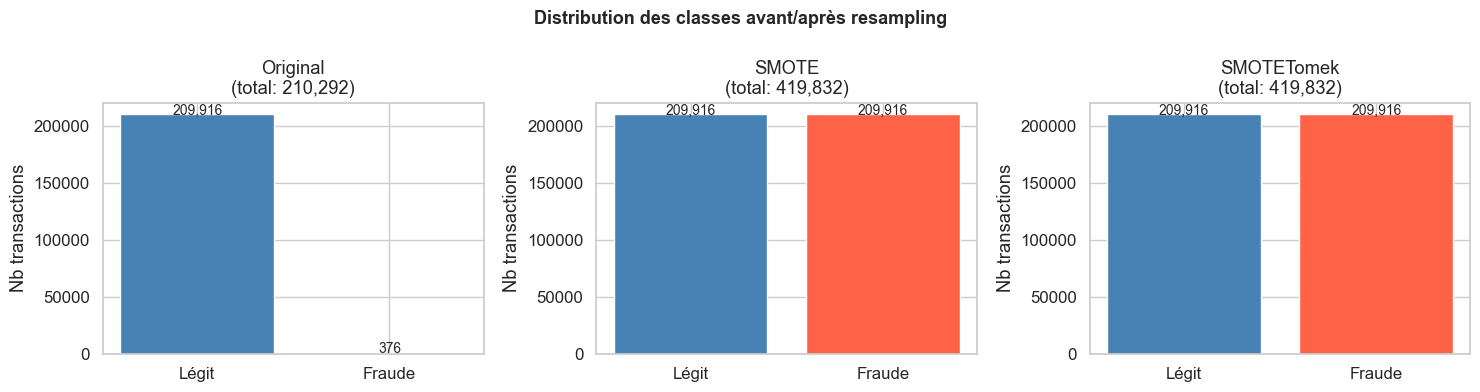

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classes après chaque stratégie
strategies = [
    ('Original', y_train),
    ('SMOTE', y_sm),
    ('SMOTETomek', y_smt),
]
for ax, (name, y) in zip(axes, strategies):
    counts = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(['Légit', 'Fraude'], counts.values,
                  color=['steelblue', 'tomato'], edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{v:,}', ha='center', fontsize=10)
    ax.set_title(f'{name}\n(total: {len(y):,})')
    ax.set_ylabel('Nb transactions')

plt.suptitle('Distribution des classes avant/après resampling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig13_resampling_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Sélection finale

On choisit la stratégie à utiliser en Phase 6–7 selon les résultats AUPRC.

In [8]:
best = df_res.iloc[0]
print('=== Stratégie retenue ===')
print(f'  Nom       : {best["Stratégie"]}')
print(f'  AUPRC     : {best["AUPRC"]}')
print(f'  Rappel    : {best["Rappel fraude"]}')
print(f'  Précision : {best["Précision fraude"]}')
print(f'  F1        : {best["F1 fraude"]}')

# Sauvegarder la recommandation
recommendation = {
    'best_strategy'    : best['Stratégie'],
    'auprc'            : best['AUPRC'],
    'all_results'      : df_res.to_dict(orient='records')
}
with open(MODELS_PATH / 'resampling_results.json', 'w') as f:
    json.dump(recommendation, f, indent=2)
print('\nRésultats sauvegardés : models/resampling_results.json')

=== Stratégie retenue ===
  Nom       : 4 — SMOTETomek
  AUPRC     : 0.7966
  Rappel    : 0.8969
  Précision : 0.0228
  F1        : 0.0444

Résultats sauvegardés : models/resampling_results.json


## 7. Conclusions

### Résultats comparatifs (LogisticRegression — test)

| # | Stratégie | AUPRC | Rappel | Précision | F1 | n_train |
|---|---|---|---|---|---|---|
| 3 & 4 | **SMOTE / SMOTETomek** | **0.7966** | 0.897 | 0.023 | 0.044 | 419 832 |
| 1 | class_weight balanced | 0.7845 | 0.907 | 0.023 | 0.045 | 210 292 |
| 0 | Aucun resampling | 0.7406 | 0.577 | 0.824 | 0.679 | 210 292 |
| 2 | Random Undersampling | 0.5606 | 0.907 | 0.019 | 0.037 | 752 |

### Analyse des résultats

| Observation | Interprétation |
|---|---|
| SMOTE = SMOTETomek (AUPRC 0.797) | Ex-aequo sur LR — SMOTETomek retenu (nettoie la frontière) |
| Random Undersampling très mauvais (0.561) | Réduire à 752 lignes détruit trop d'information |
| "Aucun resampling" : précision 0.82 mais rappel 0.58 | Rate 42 % des fraudes — inacceptable |
| SMOTE : rappel 0.90 mais précision 0.02 | Beaucoup de FP — le seuil sera tuné en Phase 9 |
| SMOTE génère 209 540 fraudes synthétiques | Train équilibré 50/50 (419 832 lignes au total) |

### Spot-check SMOTE — clarification importante

| Vérification | Résultat | Explication |
|---|---|---|
| `Amount_log1p >= 0` | **False** (min = −1.30) | **Normal** : c'est la feature *après* `RobustScaler` (centrée sur la médiane). Une valeur négative = montant en dessous de la médiane, pas un montant brut négatif. |
| `hour_sin in [−1, 1]` | **OK** | Encodage cyclique respecté |
| `is_night in [0, 1]` | **OK** | Feature binaire respectée |

> **Pas d'artefact réel** : l'alerte sur `Amount_log1p` était une fausse alarme.  
> Les distributions SMOTE (mean, std, min, max) sont très proches des fraudes réelles.

### Stratégie retenue pour Phase 6–7

> **SMOTETomek** — AUPRC 0.7966 sur LogisticRegression

**Nuance importante** : ces résultats sont sur LR (modèle linéaire rapide).  
Sur LightGBM (Phase 6–7), `class_weight='balanced'` peut rivaliser ou surpasser SMOTE  
car les GBM gèrent nativement le déséquilibre via `scale_pos_weight`.  
→ Les **deux stratégies seront comparées sur LightGBM** en Phase 7.

### Fichiers produits
- `models/resampling_results.json` — scores des 5 stratégies
- `reports/fig12_precision_recall_resampling.png` — courbes PR
- `reports/fig13_resampling_distribution.png` — distribution avant/après